# E-Commerce Sales & Customer Behavior Analysis
> End-to-end analysis of 1,000 customers, 5,000 orders, and 8,000 order items spanning 2022–2023

**Author:** P Manohar Reddy  
**Dataset:** Synthetic Indian e-commerce data (seed=42)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SQLAlchemy, Scikit-learn

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
customers   = pd.read_csv('../data/processed/customers_clean.csv')
products    = pd.read_csv('../data/processed/products_clean.csv')
orders      = pd.read_csv('../data/processed/orders_clean.csv')
order_items = pd.read_csv('../data/processed/order_items_clean.csv')
rfm         = pd.read_csv('../data/processed/rfm_scores.csv')

print(f'Customers  : {customers.shape}')
print(f'Products   : {products.shape}')
print(f'Orders     : {orders.shape}')
print(f'Order Items: {order_items.shape}')
print(f'RFM Scores : {rfm.shape}')

Customers  : (1000, 11)
Products   : (100, 9)
Orders     : (5000, 12)
Order Items: (8000, 7)
RFM Scores : (960, 10)


In [3]:
customers.head()

,customer_id,name,email,phone,gender,city,state,country,registration_date,customer_segment,tenure_days
0,C0001,Anay Shanker,nirvaan32@example.net,918196001338,Male,Nagpur,Maharashtra,India,2021-09-08,New,845
1,C0002,Jhanvi Chaudhary,cchoudhary@example.net,265423511,Male,Hyderabad,Telangana,India,2022-08-28,Regular,491
2,C0003,Divit Gola,lavanya40@example.net,8161849593,Male,Mysuru,Karnataka,India,2021-08-27,Regular,857
3,C0004,Azad Sahota,trishadhillon@example.org,911647525534,Male,Warangal,Telangana,India,2022-10-28,Regular,430
4,C0005,Mahika Ravi,hazelsethi@example.org,917648350305,Female,Janakpuri,Delhi,India,2022-08-27,New,492


In [4]:
orders.head()

,order_id,customer_id,order_date,status,payment_method,shipping_city,shipping_state,order_year,order_month,order_quarter,order_weekday,order_week_number
0,ORD00001,C0546,2022-05-02,Delivered,Net Banking,Belagavi,Karnataka,2022,5,Q2,Monday,18
1,ORD00002,C0784,2022-11-23,Cancelled,Credit Card,Chennai,Tamil Nadu,2022,11,Q4,Wednesday,47
2,ORD00003,C0454,2023-10-15,Pending,UPI,Udaipur,Rajasthan,2023,10,Q4,Sunday,41
3,ORD00004,C0135,2022-07-09,Delivered,COD,New Delhi,Delhi,2022,7,Q3,Saturday,27
4,ORD00005,C0621,2023-08-04,Delivered,Credit Card,Gwalior,Madhya Pradesh,2023,8,Q3,Friday,31


## 2. Dataset Overview & Summary Statistics

In [5]:
print('=== CUSTOMER TENURE (days) ===')
print(customers['tenure_days'].describe())
print('\n=== PRODUCT PROFIT MARGIN (%) ===')
print(products['profit_margin'].describe())
print('\n=== ORDER STATUS DISTRIBUTION ===')
print(orders['status'].value_counts())

=== CUSTOMER TENURE (days) ===
count   1,000.00
mean      720.30
std       208.76
min       365.00
25%       541.75
50%       715.50
75%       903.25
max     1,095.00
Name: tenure_days, dtype: float64

=== PRODUCT PROFIT MARGIN (%) ===
count   100.00
mean     30.81
std       6.07
min      20.20
25%      25.63
50%      31.50
75%      36.00
max      39.99
Name: profit_margin, dtype: float64

=== ORDER STATUS DISTRIBUTION ===
status
Delivered    3470
Pending       522
Returned      507
Cancelled     501
Name: count, dtype: int64


## 3. Revenue Analysis

In [6]:
engine = create_engine('sqlite:///../data/raw/ecommerce.db')
with engine.connect() as conn:
    revenue_by_category = pd.read_sql(text("""
        SELECT p.category,
               COUNT(DISTINCT o.order_id) as total_orders,
               ROUND(SUM(oi.total_price), 2) as total_revenue,
               ROUND(AVG(oi.total_price), 2) as avg_item_value
        FROM order_items oi
        JOIN orders   o ON oi.order_id   = o.order_id
        JOIN products p ON oi.product_id = p.product_id
        WHERE o.status = 'Delivered'
        GROUP BY p.category
        ORDER BY total_revenue DESC
    """), conn)
print(revenue_by_category)

         category  total_orders  total_revenue  avg_item_value
0     Electronics           745  14,866,528.50       17,428.52
1          Sports           788  11,116,334.00       12,462.26
2  Home & Kitchen           834  11,019,213.50       11,478.35
3        Clothing           814   6,131,214.00        6,649.91
4          Beauty           851   4,071,746.50        4,180.44
5           Books           810   1,608,976.00        1,739.43


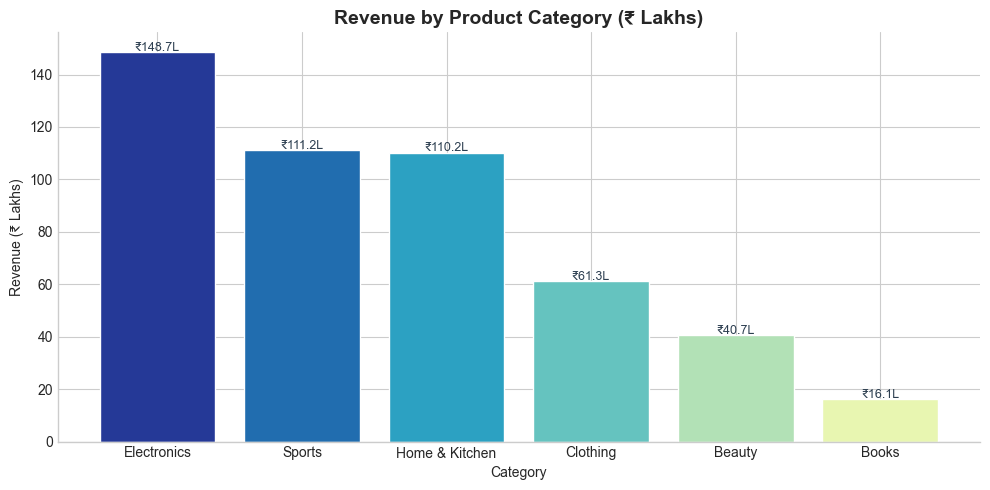

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('YlGnBu', len(revenue_by_category))[::-1]
bars = ax.bar(
    revenue_by_category['category'],
    revenue_by_category['total_revenue'] / 1e5,
    color=palette, edgecolor='white'
)
ax.set_title('Revenue by Product Category (\u20B9 Lakhs)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Revenue (\u20B9 Lakhs)')
for bar, val in zip(bars, revenue_by_category['total_revenue']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'\u20B9{val/1e5:.1f}L',
            ha='center', fontsize=9, color='#2c3e50')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Customer Segmentation & RFM Analysis

In [8]:
rfm_dist = rfm['rfm_segment'].value_counts().reset_index()
rfm_dist.columns = ['Segment', 'Count']
rfm_dist['Percentage'] = (rfm_dist['Count'] / rfm_dist['Count'].sum() * 100).round(1)
print(rfm_dist.to_string(index=False))

        Segment  Count  Percentage
Loyal Customers    426       44.40
         Others    246       25.60
        At Risk    118       12.30
           Lost    116       12.10
      Champions     54        5.60


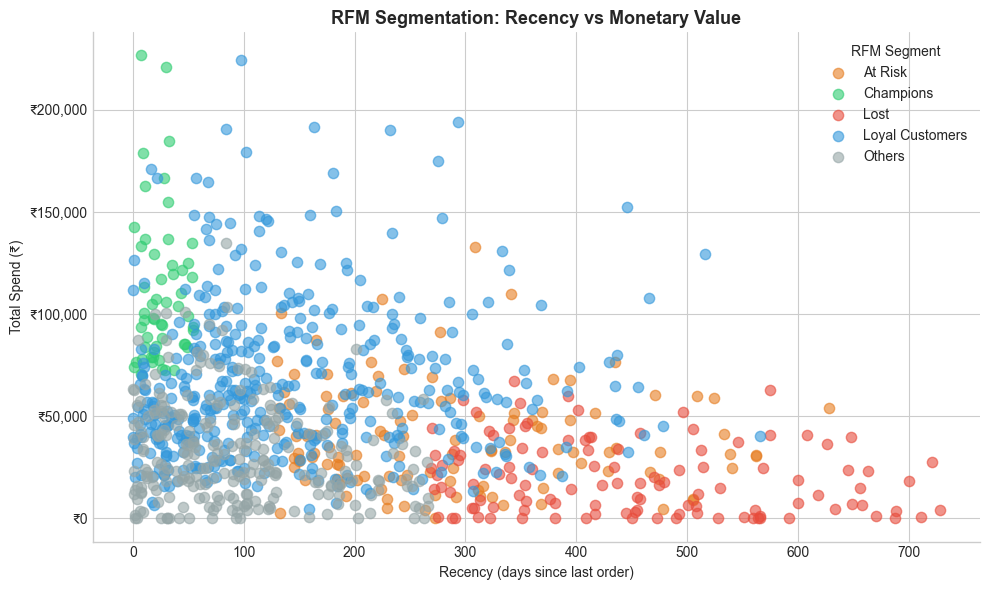

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
seg_colors = {
    'Champions':       '#2ecc71',
    'Loyal Customers': '#3498db',
    'At Risk':         '#e67e22',
    'Lost':            '#e74c3c',
    'Others':          '#95a5a6'
}
for segment, group in rfm.groupby('rfm_segment'):
    ax.scatter(
        group['recency'], group['monetary'],
        label=segment, alpha=0.6, s=55,
        color=seg_colors.get(segment, '#95a5a6')
    )
ax.set_xlabel('Recency (days since last order)')
ax.set_ylabel('Total Spend (\u20B9)')
ax.set_title('RFM Segmentation: Recency vs Monetary Value', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'\u20B9{x:,.0f}'))
ax.legend(title='RFM Segment', framealpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Monthly Revenue Trend

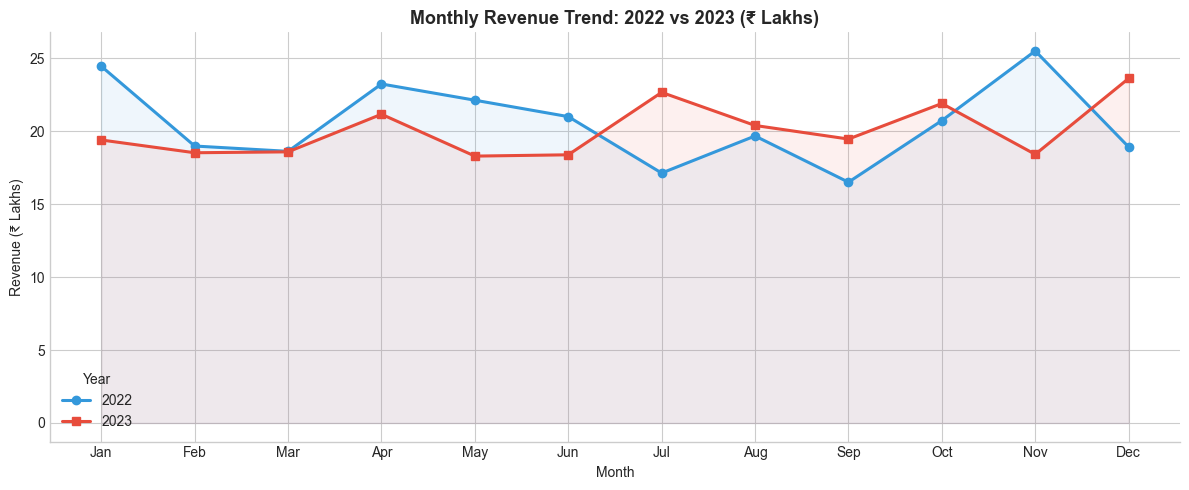

In [10]:
monthly = pd.read_csv('../data/processed/dashboard_exports/monthly_revenue.csv')
monthly_2022 = monthly[monthly['year'] == 2022]
monthly_2023 = monthly[monthly['year'] == 2023]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_2022['month'], monthly_2022['total_revenue'] / 1e5,
        marker='o', label='2022', linewidth=2.2, color='#3498db')
ax.fill_between(monthly_2022['month'], monthly_2022['total_revenue'] / 1e5,
                alpha=0.08, color='#3498db')
ax.plot(monthly_2023['month'], monthly_2023['total_revenue'] / 1e5,
        marker='s', label='2023', linewidth=2.2, color='#e74c3c')
ax.fill_between(monthly_2023['month'], monthly_2023['total_revenue'] / 1e5,
                alpha=0.08, color='#e74c3c')
ax.set_title('Monthly Revenue Trend: 2022 vs 2023 (\u20B9 Lakhs)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (\u20B9 Lakhs)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Year', framealpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Key Insights & Business Recommendations

### 📊 Key Findings

| Metric | Value |
|--------|-------|
| Total Revenue | ₹4.88 Crore |
| Top Category | Electronics (₹1.48 Cr) |
| Top Payment Method | UPI (35.3%) |
| Peak AOV Month | November 2022 (₹21,608) |
| Champion Customers | 54 (5.6%) — avg spend ₹1,10,257 |
| At Risk Customers | 118 (12.3%) — last order 288 days ago |

### 💡 Business Recommendations

1. **Re-engage At Risk customers** — 118 customers haven’t ordered in ~288 days. Target with personalised discount campaigns via UPI cashback offers (preferred payment).
2. **Reward Champions** — 54 high-value customers drive outsized revenue. Introduce a loyalty tier with early access to new Electronics products (top category).
3. **Reduce return rate** — Analyse return reasons by category and add better product descriptions and size guides to reduce friction.
4. **Capitalise on November peak** — AOV spikes in November (festive season). Plan inventory and marketing campaigns around Diwali/year-end sales.
5. **Grow UPI + Credit Card share** — Together they cover 60% of orders. Offer exclusive UPI cashback and credit card EMI options to increase basket size.

## 7. Conclusion

This analysis covered the complete data analytics pipeline:
- ✅ Synthetic dataset generation (14,100 rows across 4 tables)
- ✅ Data cleaning and feature engineering (RFM scoring, time features, profit margins)
- ✅ SQL-based business queries (8 key queries)
- ✅ Exploratory data analysis (8 visualisations)
- ✅ Customer segmentation (RFM + KMeans-ready exports)
- ✅ Dashboard exports for Tableau and Power BI

**Next Steps:** Build interactive Tableau and Power BI dashboards using the exports in `data/processed/dashboard_exports/`